In [1]:
import awkward as ak
import pyarrow as pa
import numpy as np

from datasets import load_dataset

In [2]:
# Load data from data/parsed

train_data = np.load("data/parsed/train.npz")
test_data = np.load("data/parsed/test.npz")
print("Train data keys:", train_data.files)


Train data keys: ['inputs', 'targets', 'feature_labels', 'class_labels', 'extra_vars']


# Plot the distribution of labels

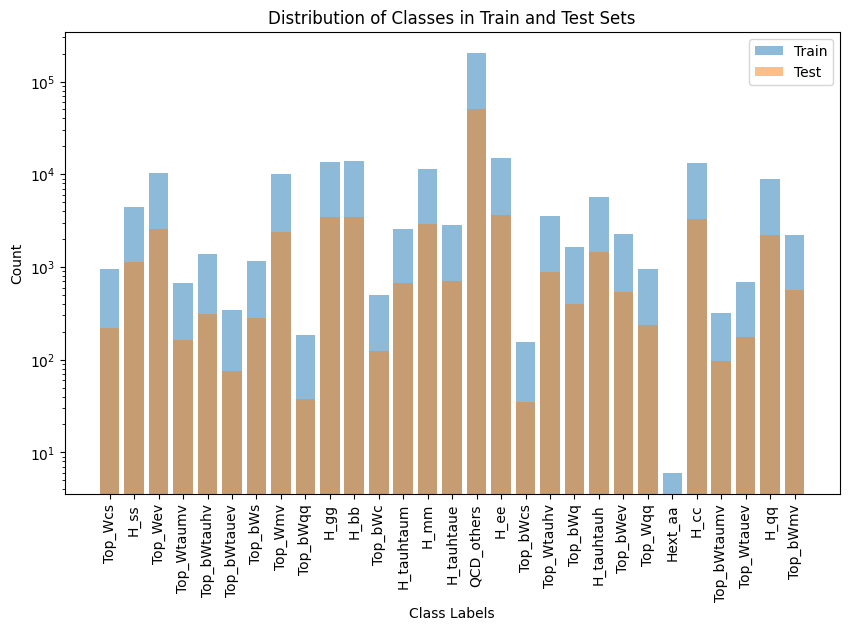

In [3]:
import matplotlib.pyplot as plt

train_counts = np.sum(train_data["targets"], axis=0)
test_counts = np.sum(test_data["targets"], axis=0)

plt.figure(figsize=(10,6))
plt.bar(train_data["class_labels"], train_counts, alpha=0.5, label="Train")
plt.bar(test_data["class_labels"], test_counts, alpha=0.5, label="Test")
plt.xticks(rotation=90)
plt.xlabel("Class Labels")
plt.ylabel("Count")
#plt.ylim(0, 2500)  # Set y-axis limit for better visibility
plt.yscale("log")  # Use logarithmic scale for better visibility
plt.title("Distribution of Classes in Train and Test Sets")
plt.legend()
plt.show()

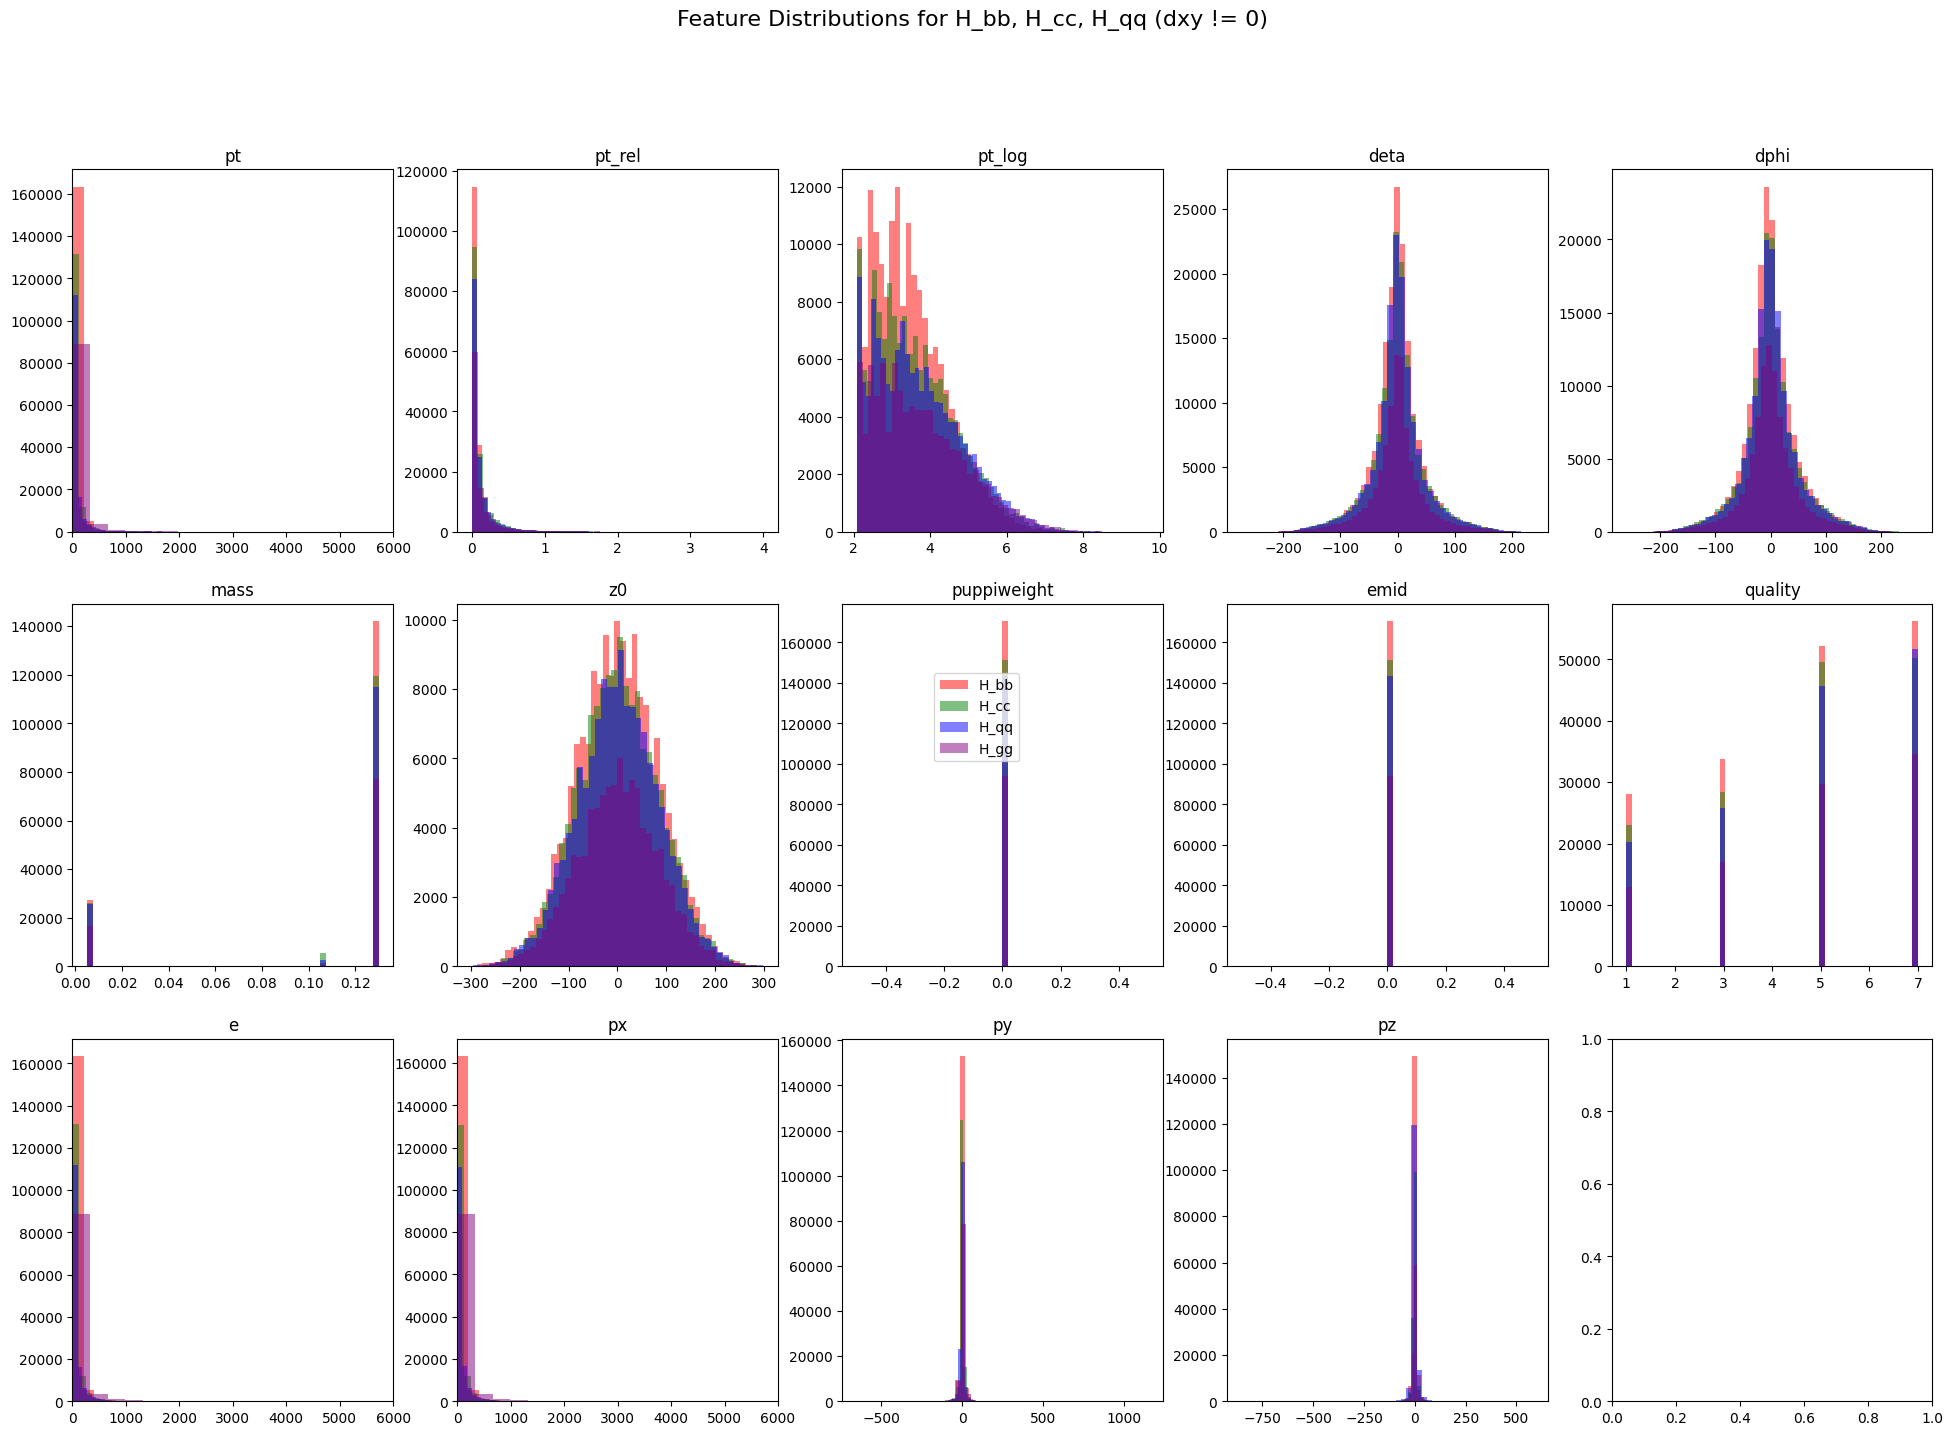

In [14]:



subset_classes = ["H_bb", "H_cc", "H_qq", "H_gg"]
subset_label_idx = [i for i, label in enumerate(train_data["class_labels"]) if label in subset_classes]
subset_mask = np.isin(train_data["targets"].argmax(axis=1), subset_label_idx)
colors = ["red", "green", "blue", "purple"]
cl_to_col = {label: color for label, color in zip(subset_classes, colors)}

fig, ax = plt.subplots(figsize=(24,16), nrows=3, ncols=5)
ax = ax.flatten()

for idx, label in zip(subset_label_idx, subset_classes):
    mask = np.isin(train_data["targets"].argmax(axis=1), idx)
    subset_features = train_data["inputs"][mask]

    feature_names = train_data["feature_labels"]


    features = dict(zip(feature_names, subset_features.T))
    isfilled = features["isfilled"].astype(bool)
    features = {k: v[isfilled] for k, v in features.items() if "is" not in k}
    dxy = features["dxy"]
    # Filter out entries where dxy == 0
    features = {k: v[dxy != 0] for k, v in features.items() if k not in ["dxy", "isfilled"]} 

    i = 0   
    for name, values in features.items():
        if "is" in name:
            continue  # Skip binary features
        if np.ndim(values) > 1:
            values = values.flatten()
        ax[i].hist(values, bins=50, color=cl_to_col[label], alpha=0.5)
        ax[i].set_title(name)
        #ax[i].set_yscale("log")
        #ax[i].sharey(ax[0])  # Share y-axis across all subplots
        if name in ["pt", "e", "px"]:
            ax[i].set_xlim(0, 6000)

        i += 1
#plt.tight_layout()
fig.suptitle("Feature Distributions for H_bb, H_cc, H_qq (dxy != 0)", fontsize=16)
fig.legend(subset_classes, loc="center")
plt.show()

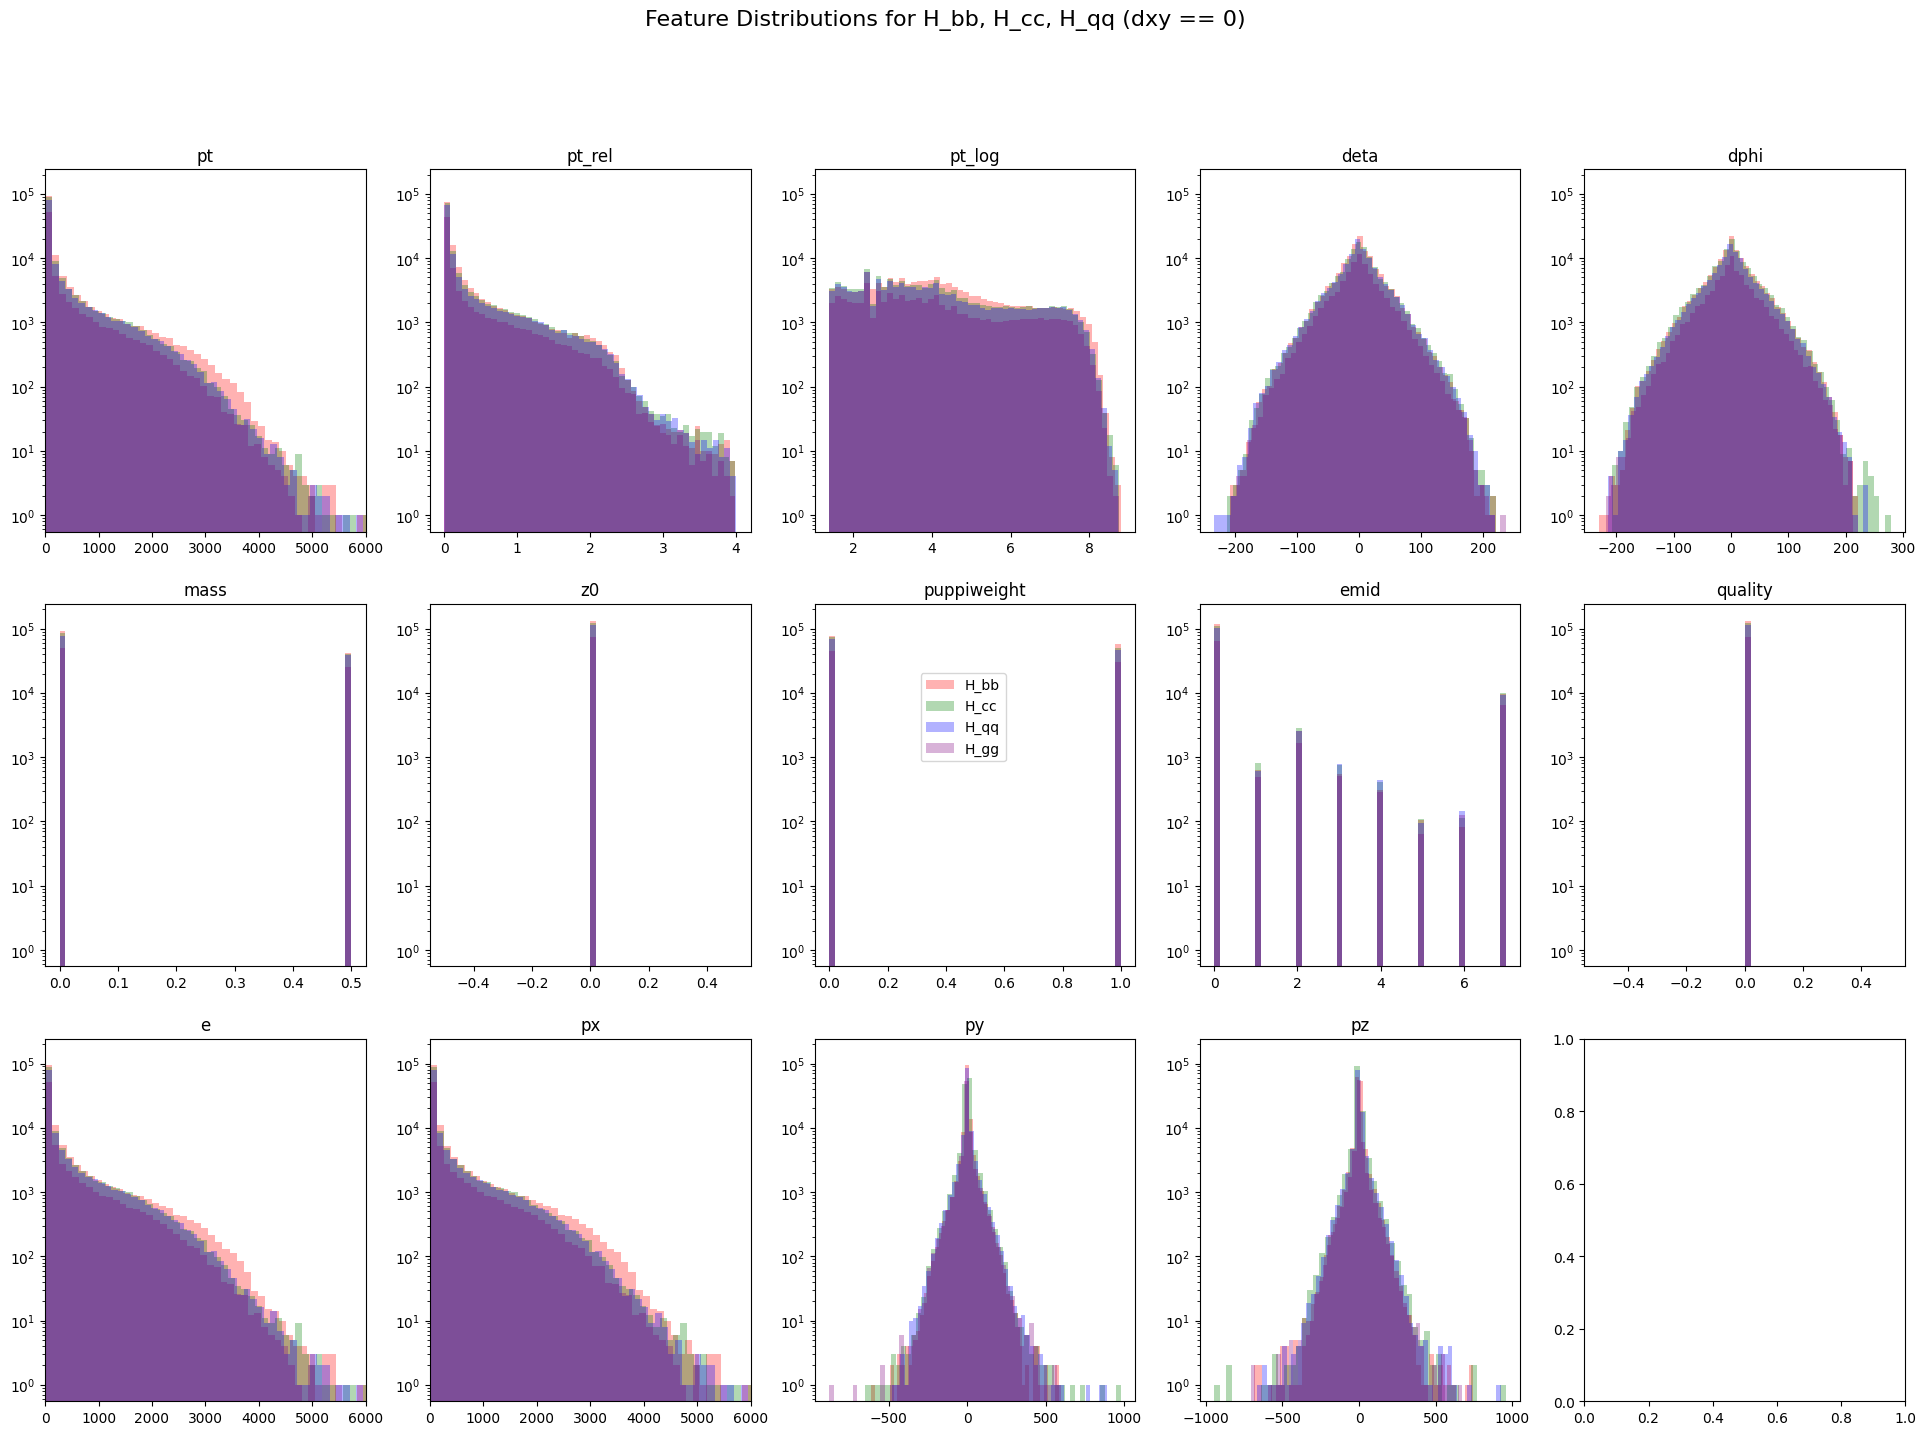

In [10]:
    
fig, ax = plt.subplots(figsize=(24, 16), nrows=3, ncols=5)
ax = ax.flatten()

for idx, label in zip(subset_label_idx, subset_classes):
    mask = np.isin(train_data["targets"].argmax(axis=1), idx)
    subset_features = train_data["inputs"][mask]

    feature_names = train_data["feature_labels"]

    features = dict(zip(feature_names, subset_features.T))
    isfilled = features["isfilled"].astype(bool)
    features = {k: v[isfilled] for k, v in features.items() if "is" not in k}
    dxy = features["dxy"]
    features = {
        k: v[dxy == 0] for k, v in features.items() if k not in ["dxy", "isfilled"]
    }

    i = 0
    for name, values in features.items():
        if "is" in name:
            continue  # Skip binary features
        if np.ndim(values) > 1:
            values = values.flatten()
        ax[i].hist(values, bins=50, color=cl_to_col[label], alpha=0.3)
        ax[i].set_title(name)
        ax[i].set_yscale("log")
        ax[i].sharey(ax[0])  # Share y-axis across all subplots
        if name in ["pt", "e", "px"]:
            ax[i].set_xlim(0, 6000)

        i += 1
# plt.tight_layout()
fig.suptitle("Feature Distributions for H_bb, H_cc, H_qq (dxy == 0)", fontsize=16)
fig.legend(subset_classes, loc="center")
plt.show()


In [30]:
features = dict(zip(feature_names,  train_data["inputs"].T))


In [34]:
non_zero_dxy = features["dxy"][features["dxy"] != 0]
mean_dxy = np.mean(non_zero_dxy)
std_dxy = np.std(non_zero_dxy)

print(f"Mean of dxy: {mean_dxy}")
print(f"Standard Deviation of dxy: {std_dxy}")

puppi = features["puppiweight"][features["puppiweight"] != 0]
mean_puppi = np.mean(puppi)
std_puppi = np.std(puppi)

print(f"Mean of puppi_weight: {mean_puppi}")
print(f"Standard Deviation of puppi_weight: {std_puppi}")

Mean of dxy: 4.0
Standard Deviation of dxy: 0.0
Mean of puppi_weight: 1.0
Standard Deviation of puppi_weight: 0.0


In [15]:
files = [f"data/Res2P_{num:04}.parquet" for num in range(1)]

cols_to_load = [
    "jet_label",
    "part_px",
    "part_py",
    "part_pz",
    "part_energy",
    "part_deta",
    "part_dphi",
    "part_charge",
    "part_d0val",
    "part_d0err",
    "part_dzval",
    "part_dzerr",
    "part_isElectron",
    "part_isMuon",
    "part_isChargedHadron",
    "part_isNeutralHadron",
    "part_isPhoton",
]
ds = load_dataset(
    "jet-universe/jetclass2", data_files=files, split="train", columns=cols_to_load
)

class_names = [
    "bb",
    "cc",
    "ss",
    "qq",
    "bc",
    "cs",
    "bq",
    "cq",
    "sq",
    "gg",
    "ee",
    "mumu",
    "tauhtaue",
    "tauhtaumu",
    "tauhtauh",
]

print(len(class_names))
class_map = {i: c for i, c in enumerate(class_names)}
print(len(ds))

15
100000


In [ ]:
target_classes = ["bb", "cc", "qq", "gg"]
selected_class_indices = [class_names.index(cls) for cls in target_classes]
ds_selected = ds.filter(lambda x: x["jet_label"] in selected_class_indices)
print(len(ds_selected))


29515


In [ ]:
fig, ax = plt.subplots(figsize=(24, 16), nrows=3, ncols=5)
ax = ax.flatten()

cl_to_col = {label: color for label, color in zip(target_classes, colors)}

for label in target_classes:
    class_features = ds_selected.filter(lambda x: x["jet_label"] == class_names.index(label))

    i = 0
    for name in cols_to_load[1:]:  # Skip jet_label
        values = class_features[name]
        if "is" in name:
            continue 
        values = np.concatenate([np.asarray(v) for v in values if len(v) > 0])
        ax[i].hist(values, bins=50, color=cl_to_col[label], alpha=0.3)
        ax[i].set_title(name)
        #ax[i].set_yscale("log")
        i += 1
# plt.tight_layout()
fig.legend(target_classes, loc="center")
plt.show()
